# Thống Kê và Trực Quan Hóa Dữ Liệu Chunks (RAG Pipeline)
Notebook này phân tích các file `parents.json` và `children.json` để đánh giá chất lượng của phương pháp Hybrid Hierarchical Chunking.

In [29]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [30]:
# 1. Đọc dữ liệu
with open('../data/parents.json', 'r', encoding='utf-8') as f:
    parents = json.load(f)
with open('../data/children.json', 'r', encoding='utf-8') as f:
    children = json.load(f)

# 2. Chuyển đổi thành DataFrame
df_parents = pd.DataFrame(parents)
df_children = pd.DataFrame(children)

# Tính toán độ dài ký tự
df_parents['char_length'] = df_parents['text'].apply(len)
df_children['char_length'] = df_children['text'].apply(len)

In [31]:
# 3. Thống kê tổng quan
print("===== THỐNG KÊ TỔNG QUAN =====")
print(f"Tổng số Parent Chunks: {len(df_parents):,}")
print(f"Tổng số Child Chunks: {len(df_children):,}")
print(f"Tỷ lệ nở (Child/Parent): {len(df_children)/len(df_parents):.2f} children/parent")
print(f"Độ dài trung bình Parent: {df_parents['char_length'].mean():.0f} ký tự")
print(f"Độ dài trung bình Child: {df_children['char_length'].mean():.0f} ký tự")
print(f"Độ dài lớn nhất Child: {df_children['char_length'].max()} ký tự")

===== THỐNG KÊ TỔNG QUAN =====
Tổng số Parent Chunks: 790
Tổng số Child Chunks: 2,899
Tỷ lệ nở (Child/Parent): 3.67 children/parent
Độ dài trung bình Parent: 1428 ký tự
Độ dài trung bình Child: 479 ký tự
Độ dài lớn nhất Child: 915 ký tự


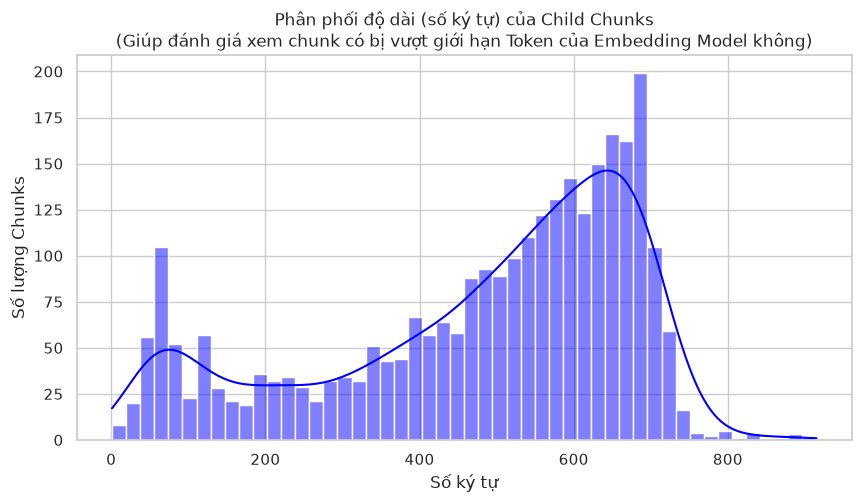

In [32]:
# 4. Phân phối độ dài của Child Chunks
plt.figure(figsize=(10, 5))
sns.histplot(df_children['char_length'], bins=50, kde=True, color='blue')
plt.title('Phân phối độ dài (số ký tự) của Child Chunks\n(Giúp đánh giá xem chunk có bị vượt giới hạn Token của Embedding Model không)')
plt.xlabel('Số ký tự')
plt.ylabel('Số lượng Chunks')
plt.show()

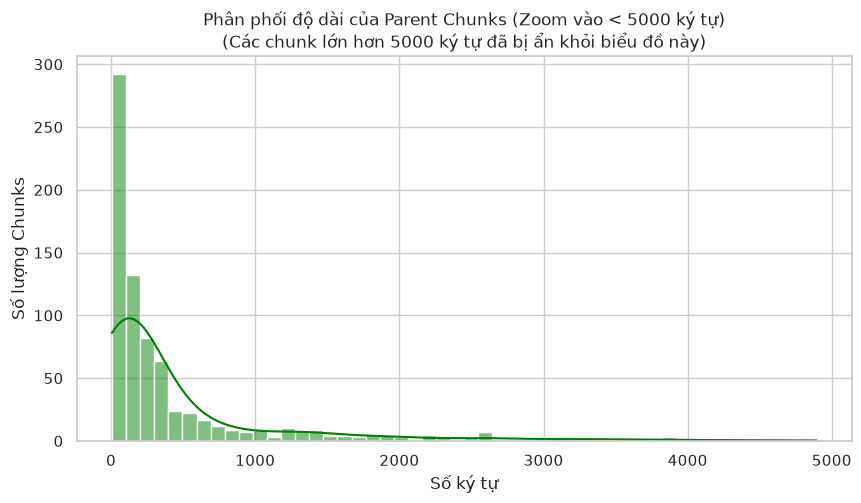

In [33]:
# 5. Phân phối độ dài của Parent Chunks (Loại bỏ các Outlier khổng lồ để dễ nhìn)
plt.figure(figsize=(10, 5))
filtered_parents = df_parents[df_parents['char_length'] <= 5000]
sns.histplot(filtered_parents['char_length'], bins=50, kde=True, color='green')
plt.title('Phân phối độ dài của Parent Chunks (Zoom vào < 5000 ký tự)\n(Các chunk lớn hơn 5000 ký tự đã bị ẩn khỏi biểu đồ này)')
plt.xlabel('Số ký tự')
plt.ylabel('Số lượng Chunks')
plt.show()

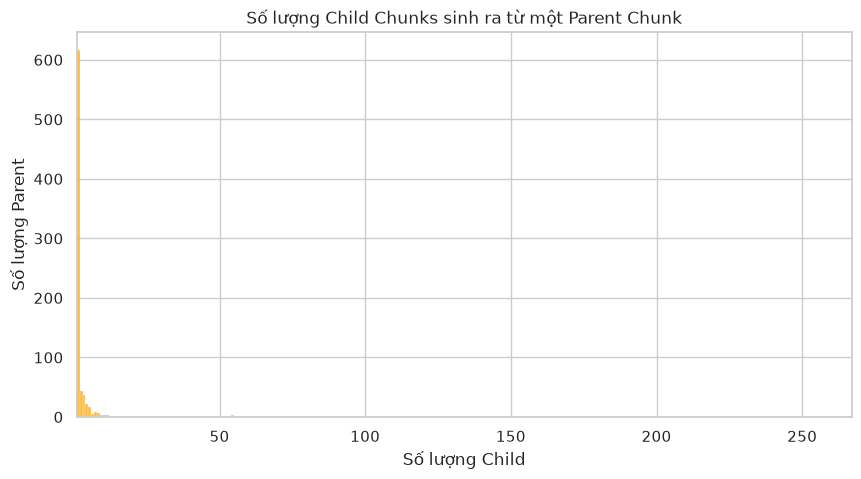

Nhiều nhất một Parent bị cắt thành 266 Children.


In [34]:
# 6. Tần suất chia nhỏ (Bao nhiêu Child được đẻ ra từ 1 Parent)
child_counts = df_children['parent_id'].value_counts()

plt.figure(figsize=(10, 5))
sns.histplot(child_counts, bins=range(1, child_counts.max() + 2), kde=False, color='orange')
plt.title('Số lượng Child Chunks sinh ra từ một Parent Chunk')
plt.xlabel('Số lượng Child')
plt.ylabel('Số lượng Parent')
plt.xlim(1, child_counts.max() + 1)
plt.show()

print(f"Nhiều nhất một Parent bị cắt thành {child_counts.max()} Children.")

/tmp/ipykernel_63084/260283332.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=source_counts.values, y=source_counts.index, palette='viridis')
/tmp/ipykernel_63084/260283332.py:10: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


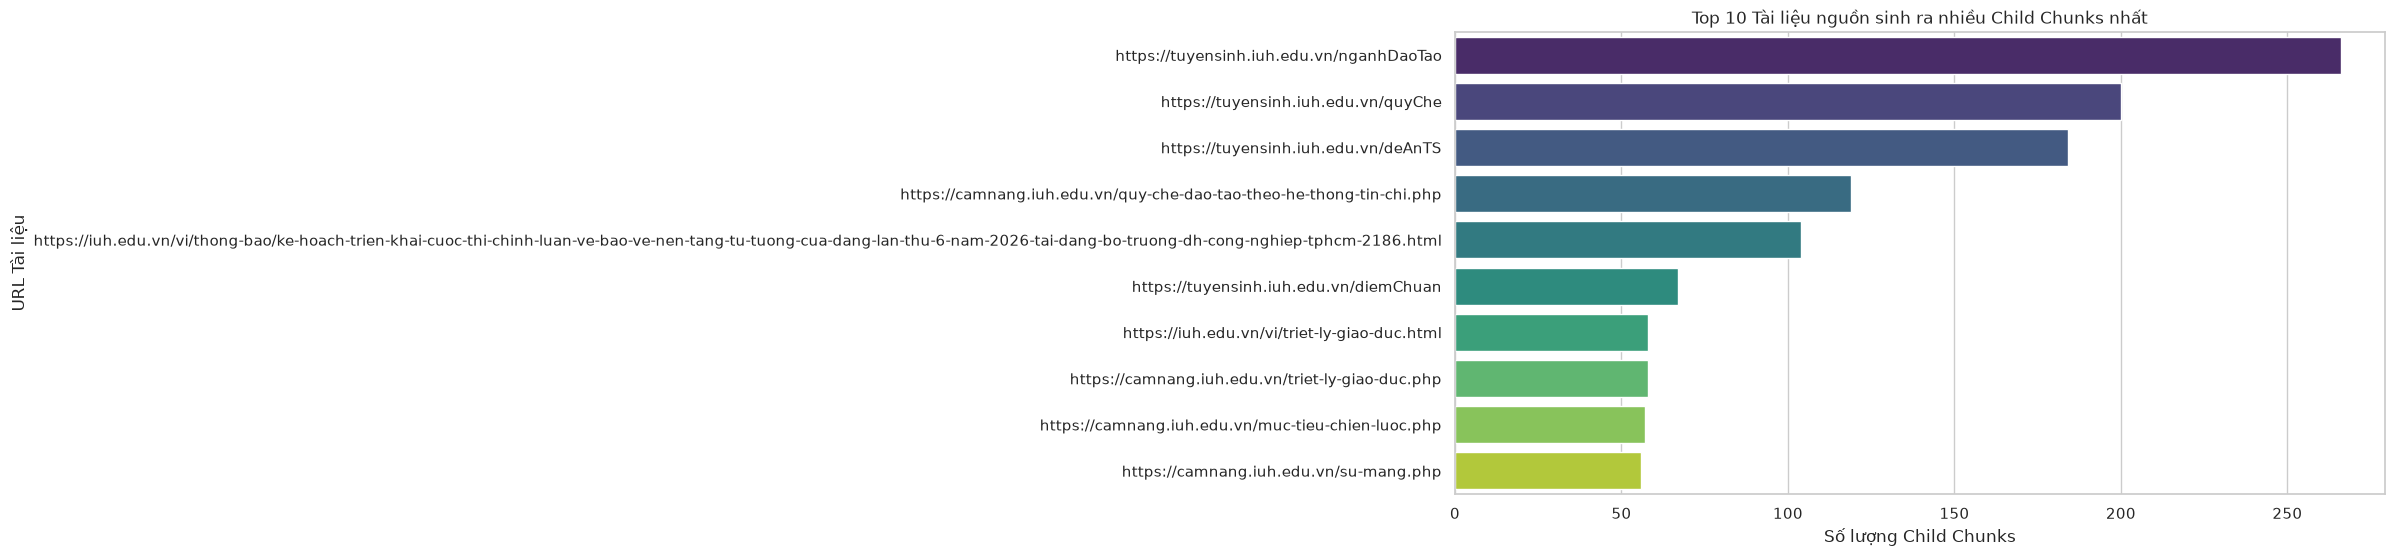

In [35]:
# 7. Thống kê theo từng tài liệu nguồn (Source URL)
df_children['source_url'] = df_children['metadata'].apply(lambda x: x.get('source_url', 'Unknown'))
source_counts = df_children['source_url'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=source_counts.values, y=source_counts.index, palette='viridis')
plt.title('Top 10 Tài liệu nguồn sinh ra nhiều Child Chunks nhất')
plt.xlabel('Số lượng Child Chunks')
plt.ylabel('URL Tài liệu')
plt.tight_layout()
plt.show()